<class 'numpy.ndarray'>


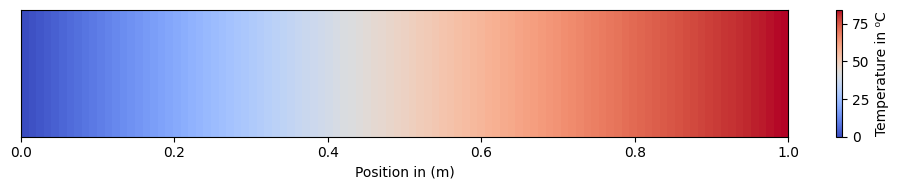

In [37]:
## Import Libraries
import numpy as np
import matplotlib.pyplot as plt

## System Parameters
L=1 # rod length
delx=0.01 # element length
deltt=0.01 # time step
T=10 # Simulation time

## Space Discretization
X=np.linspace(0,1,101) 
print(type(X))
## Initial Condition
Temperature_initial=100*np.sin(X)
temp_curr=Temperature_initial
#print(temp_curr[-1])
temp_next=np.array([])
Temperature=[]

## plot initial_condition
fig,ax=plt.subplots(figsize=(10,2))
extent=[0,1,0,0.5]
img=ax.imshow(Temperature_initial[np.newaxis,:],cmap="coolwarm",aspect="auto",extent=extent)
plt.xlabel("Position in (m)")
plt.yticks([])
plt.colorbar(img,ax=ax,label="Temperature in ⁰C")
plt.tight_layout()
plt.savefig("Initial_Condition.png")

In [ ]:
## Solve the equation by Central Difference Method

temp_curr=Temperature_initial
print(temp_curr)
for t in range(0,int(T/deltt),1):
    for i in range(1,len(Temperature_initial)-1):
        tem_nxt=temp_curr[i] + (deltt/delx**2) * (temp_curr[i-1]- 2*temp_curr[i] + temp_curr[i+1])
        temp_next=np.append(temp_next,tem_nxt)
    temp_curr=temp_next
    Temperature.append(temp_curr)

[ 0.          0.99998333  1.99986667  2.99955002  3.99893342  4.99791693
  5.99640065  6.99428473  7.9914694   8.98785492  9.98334166 10.97783008
 11.97122073 12.96341426 13.95431146 14.94381325 15.93182066 16.91823491
 17.90295734 18.8858895  19.86693308 20.84598998 21.82296231 22.79775235
 23.77026264 24.74039593 25.70805519 26.67314367 27.63556486 28.59522251
 29.55202067 30.50586364 31.45665606 32.40430284 33.34870921 34.28978075
 35.22742333 36.1615432  37.09204694 38.01884151 38.94183423 39.8609328
 40.77604531 41.68708024 42.59394651 43.49655341 44.3948107  45.28862854
 46.17791755 47.06258882 47.94255386 48.81772469 49.68801378 50.55333412
 51.41359917 52.26872289 53.11861979 53.96320487 54.80239368 55.63610229
 56.46424734 57.28674601 58.10351605 58.91447579 59.71954414 60.51864057
 61.3116852  62.0985987  62.8793024  63.65371822 64.42176872 65.1833771
 65.9384672  66.6869635  67.42879116 68.163876   68.89214451 69.61352386
 70.32794192 71.03532724 71.73560909 72.42871744 73.1

In [36]:
## create Animation
import matplotlib.animation as animation

fig,ax=plt.subplots(figsize=(10,2))
extent=[0,1,0,0.5]
img=ax.imshow(Temperature_initial[np.newaxis,:],cmap="coolwarm",aspect="auto",extent=extent)
plt.xlabel("Position in (m)")
plt.colorbar(img,ax=ax,label="Temperature in ⁰C")
plt.tight_layout()

def animate(i):
    img=ax.imshow(np.array(Temperature[i])[np.newaxis,:],cmap="coolwarm",aspect="auto",extent=extent)
    plt.xlabel("Position in (m)")
    plt.colorbar(img,ax=ax,label="Temperature in ⁰C")
    plt.tight_layout()

anim=animation.FuncAnimation(fig,animate,frames=int(T/deltt)-1)
writer=animation.FFMpegWriter(fps=60)
anim.save("1D_Heat_Equation.mp4",writer=writer)


CalledProcessError: Command '['ffmpeg', '-f', 'rawvideo', '-vcodec', 'rawvideo', '-s', '1000x200', '-pix_fmt', 'rgba', '-framerate', '60', '-loglevel', 'error', '-i', 'pipe:', '-vcodec', 'h264', '-pix_fmt', 'yuv420p', '-y', '1D_Heat_Equation.mp4']' returned non-zero exit status 255.

Error in callback <function flush_figures at 0x1123d9da0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 